## Project 2  - NLP

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Pipeline
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("dataset/data.csv")

df.head()

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   
3      1  FBI Russia probe helped by Australian diplomat...   
4      1  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   
3859
3965
count    39942.000000
mean      2384.637875
st

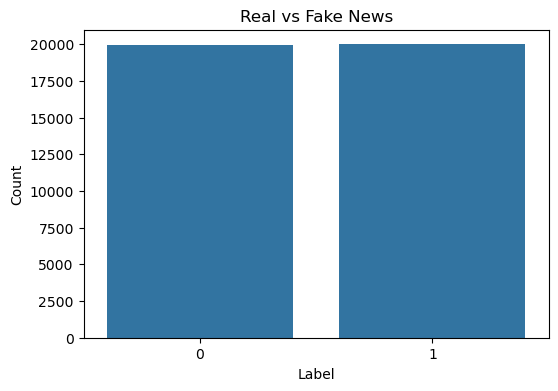

In [3]:
# Milesotne 1 - load and explore the data

#print(df.shape)
print(df.head(5))
#print(df['label'].value_counts())          # check class balance
#print(df.isnull().sum())                   # check missing values
#print(df['subject'].value_counts())        # sanity check on categories
print(df['title'].duplicated().sum())          # check for title duplicates
print(df['text'].duplicated().sum())          # check for text duplicates

# character length
df['text_char_len'] = df['text'].fillna('').apply(len)

# word count (simple split-based)
df['text_word_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))

print(df['text_char_len'].describe())
print(df['text_word_len'].describe())

plt.figure(figsize=(6,4)) 
sns.countplot(data=df, x="label") 
plt.title("Real vs Fake News") 
plt.xlabel("Label") 
plt.ylabel("Count") 
plt.show()


#keep in mind duplicates (maybe same artical in different subjects)> maybe we remove them? 


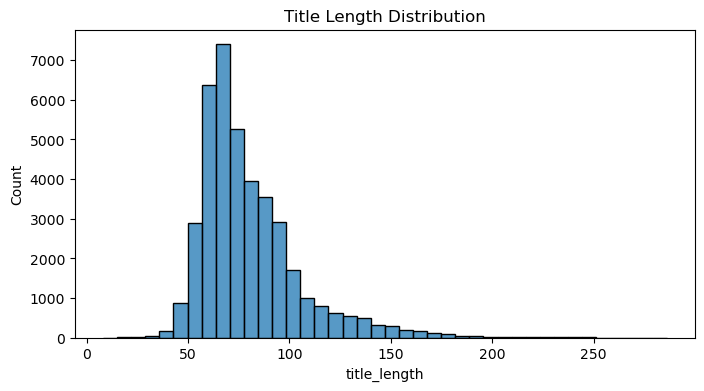

In [4]:
df["title_length"] = df["title"].str.len() 
plt.figure(figsize=(8,4)) 
sns.histplot(df["title_length"], bins=40) 
plt.title("Title Length Distribution") 
plt.show()

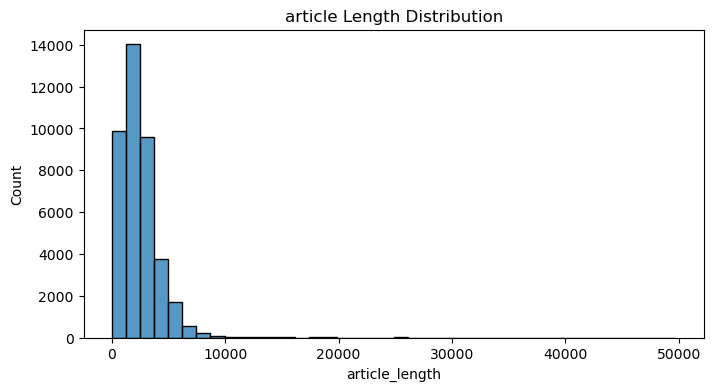

In [5]:
df["article_length"] = df["text"].str.len() 
plt.figure(figsize=(8,4)) 
sns.histplot(df["article_length"], bins=40) 
plt.title("article Length Distribution") 
plt.show()

In [6]:
'''
plt.figure(figsize=(10,6)) 
sns.countplot( data=df, y="title", hue="label", order=df["title"].value_counts().index ) 
plt.title("News title by Label") 
plt.xlabel("Count") 
plt.ylabel("Subject") 
plt.legend(title="Label", labels=["Fake", "Real"]) 
plt.show()
'''

'\nplt.figure(figsize=(10,6)) \nsns.countplot( data=df, y="title", hue="label", order=df["title"].value_counts().index ) \nplt.title("News title by Label") \nplt.xlabel("Count") \nplt.ylabel("Subject") \nplt.legend(title="Label", labels=["Fake", "Real"]) \nplt.show()\n'

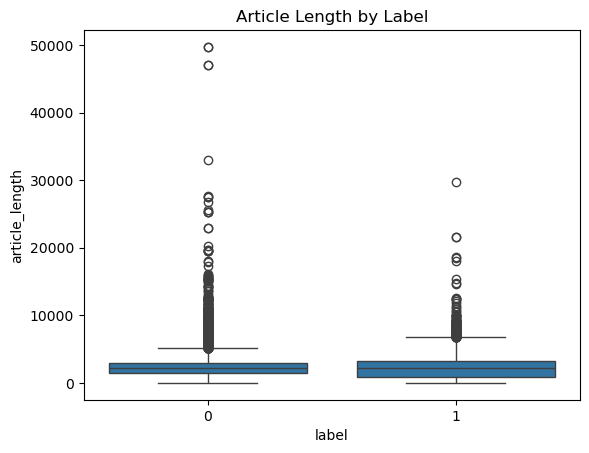

In [7]:
sns.boxplot(data=df, x="label", y="article_length")
plt.title("Article Length by Label")
plt.show()

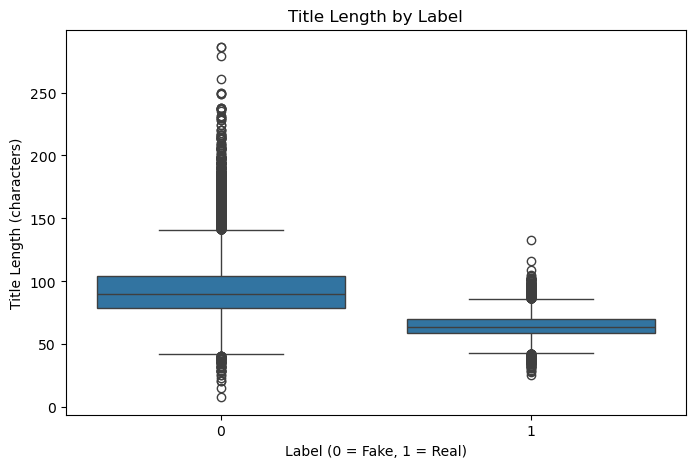

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="title_length"
)

plt.title("Title Length by Label")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Title Length (characters)")

plt.show()


In [9]:
# First 5 real news articles
df[df["label"] == 1]["text"].head(5)

0    WASHINGTON (Reuters) - The head of a conservat...
1    WASHINGTON (Reuters) - Transgender people will...
2    WASHINGTON (Reuters) - The special counsel inv...
3    WASHINGTON (Reuters) - Trump campaign adviser ...
4    SEATTLE/WASHINGTON (Reuters) - President Donal...
Name: text, dtype: object

In [10]:
# First 5 fake news articles
df[df["label"] == 0]["text"].head(5)

19999    Donald Trump just couldn t wish all Americans ...
20000    House Intelligence Committee Chairman Devin Nu...
20001    On Friday, it was revealed that former Milwauk...
20002    On Christmas day, Donald Trump announced that ...
20003    Pope Francis used his annual Christmas Day mes...
Name: text, dtype: object

"During the exploratory analysis, we observed that many real news articles begin with a Reuters location and source identifier (e.g., 'WASHINGTON (Reuters) -'). This introduces a potential source bias, as the classifier may learn to associate Reuters-specific patterns with the 'real' class rather than relying solely on the article's linguistic content."

In [11]:
# REMOVE DUPLICATES

# how many are FULL duplicates (title + text + label all identical)?
full_dupes = df.duplicated(subset=['title', 'text'], keep=False)
print("Full duplicate rows:", full_dupes.sum())

# are duplicated texts ever labeled differently? (contradiction = data quality issue)
dupe_text_groups = df[df['text'].duplicated(keep=False)].groupby('text')['label'].nunique()
conflicting = dupe_text_groups[dupe_text_groups > 1]
print("Texts with conflicting labels:", len(conflicting))

# drop full duplicates (keep first occurrence)
df = df.drop_duplicates(subset=['title', 'text'], keep='first')
print(df.shape)

# drop rows with conflicting labels entirely (can't trust either)
conflicting_texts = conflicting.index
df = df[~df['text'].isin(conflicting_texts)]
print(df.shape)

Full duplicate rows: 6885
Texts with conflicting labels: 1
(36429, 9)
(35991, 9)


In [12]:
#we want to drop columns > date & subject
df = df.drop(columns=['date', 'subject'])

print(df.shape)



(35991, 7)


In [13]:
df = df.drop(columns=[
    'text_char_len',
    'text_word_len',
    'title_length',
    'article_length'
])

In [14]:
#drop Labels to avoid data leakage

X = df.drop(columns=["label"])
y = df["label"]

print(X.head(5))

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text  
0  WASHINGTON (Reuters) - The head of a conservat...  
1  WASHINGTON (Reuters) - Transgender people will...  
2  WASHINGTON (Reuters) - The special counsel inv...  
3  WASHINGTON (Reuters) - Trump campaign adviser ...  
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  


In [15]:
#Milestone 2 — Train/test split (before any preprocessing)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)




(28792, 2) (28792,)


In [16]:
#Milestone 3 — Text cleaning
import re


def clean_text(text):

    text = text.lower()

    # Remove Reuters location prefixes
    text = re.sub(
        r'^[A-Z\s\/\-]+\s*\(Reuters\)\s*[-–]\s*',
        '',
        text,
        flags=re.IGNORECASE
    )

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Keep only letters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


X_train = X_train.copy()
X_test = X_test.copy()

X_train['title_clean'] = X_train['title'].apply(clean_text)
X_train['text_clean'] = X_train['text'].apply(clean_text)
X_test['title_clean'] = X_test['title'].apply(clean_text)
X_test['text_clean'] = X_test['text'].apply(clean_text)


print(X_train.head(5))



                                                   title  \
19281  China's ruling party expels anti-graft, ex-ins...   
33118  CLINTON GLOBAL INITIATIVE MEMBER TO Moderate F...   
28401   Heckler Crashes Ted Cruz Speech By Shouting ‘...   
3957    Florida LGBT rights push reflects changing times   
15290  SpaceX to launch Turkish satellites, minister ...   

                                                    text  \
19281  SHANGHAI (Reuters) - China s ruling Communist ...   
33118   How in the heck does the RNC keep getting the...   
28401  Hecklers at GOP rallies rarely disappoint   af...   
3957   TALLAHASSEE, Fla. (Reuters) - A Republican, a ...   
15290  ISTANBUL (Reuters) - Turkey s Turksat 5A and 5...   

                                             title_clean  \
19281  china s ruling party expels anti graft ex insu...   
33118  clinton global initiative member to moderate f...   
28401  heckler crashes ted cruz speech by shouting te...   
3957    florida lgbt rights push refle

In [17]:
# Combine title and article into a single document
X_train["combined_text"] = (
    X_train["title_clean"] + " " + X_train["text_clean"]
)

X_test["combined_text"] = (
    X_test["title_clean"] + " " + X_test["text_clean"]
)

In [18]:
# Milestone 4 — Feature extraction (combined title + text)

from sklearn.feature_extraction.text import TfidfVectorizer

# Combine title and article into one document
X_train["combined_text"] = (
    X_train["title_clean"] + " " + X_train["text_clean"]
)

X_test["combined_text"] = (
    X_test["title_clean"] + " " + X_test["text_clean"]
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=25000,
    ngram_range=(1,2)
)

X_train_combined = vectorizer.fit_transform(
    X_train["combined_text"]
)

X_test_combined = vectorizer.transform(
    X_test["combined_text"]
)

print("Feature matrix shapes:")
print(X_train_combined.shape)
print(X_test_combined.shape)

Feature matrix shapes:
(28792, 25000)
(7199, 25000)


In [19]:
# tidy up: title_clean/text_clean already vectorized, no longer needed in the dataframes
X_train = X_train.drop(columns=['title_clean', 'text_clean'])
X_test = X_test.drop(columns=['title_clean', 'text_clean'])

In [20]:
# Milestone 5 — Baseline model
# ---------------------------------------------------------------------------
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_combined,
    y_train
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


Linear SVM Results
Training Accuracy : 0.9994
Test Accuracy     : 0.9912

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3241
           1       0.99      1.00      0.99      3958

    accuracy                           0.99      7199
   macro avg       0.99      0.99      0.99      7199
weighted avg       0.99      0.99      0.99      7199


Confusion Matrix
[[3197   44]
 [  19 3939]]


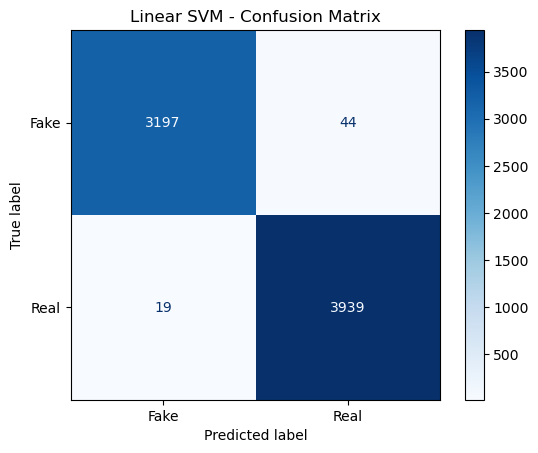

In [21]:
# ============================================================================
# Milestone 6 — Evaluation (Linear SVM)
# ============================================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# Training predictions
# -----------------------------
train_pred_svm = svm_model.predict(X_train_combined)
train_accuracy_svm = accuracy_score(y_train, train_pred_svm)

# -----------------------------
# Test predictions
# -----------------------------
test_pred_svm = svm_model.predict(X_test_combined)
test_accuracy_svm = accuracy_score(y_test, test_pred_svm)

# -----------------------------
# Print results
# -----------------------------
print("=" * 60)
print("Linear SVM Results")
print("=" * 60)

print(f"Training Accuracy : {train_accuracy_svm:.4f}")
print(f"Test Accuracy     : {test_accuracy_svm:.4f}")

print("\nClassification Report")
print(classification_report(y_test, test_pred_svm))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, test_pred_svm)
print(cm)

# -----------------------------
# Plot confusion matrix
# -----------------------------
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot(cmap="Blues")

plt.title("Linear SVM - Confusion Matrix")
plt.show()

In [ ]:

# MILESTONE 6: INFERENCE & OUTPUT SERIALIZATION

# Path Definitions
val_path = "dataset/validation_data.csv"
output_path = "dataset/validation_data.csv"

# Ingest verification dataset
df_val = pd.read_csv(val_path)

# Preprocess exactly like the training data
df_val["title_clean"] = df_val["title"].apply(clean_text)
df_val["text_clean"] = df_val["text"].apply(clean_text)
df_val["combined_text"] = df_val["title_clean"] + " " + df_val["text_clean"]

# Generate classifications 
X_val_tfidf = vectorizer.transform(df_val["combined_text"])

val_predictions = svm_model.predict(X_val_tfidf)

# ------------------------------------------------------------------------------
# NEW INSPECTION STEP: View predictions before updating the CSV
# ------------------------------------------------------------------------------
print("\n--- PRE-SAVE INSPECTION ---")

# A. Convert predictions to a quick Pandas Series to inspect class distribution
pred_series = pd.Series(val_predictions)
print("Predicted Class Counts:")
print(pred_series.value_counts())
print(
    f"Percentage of Fake (0): { (pred_series == 0).mean() * 100 :.2f}%"
)
print(
    f"Percentage of Real (1): { (pred_series == 1).mean() * 100 :.2f}%"
)

# B. Visually print the first 5 samples to audit the text vs your model's classification
print("\nAuditing first 5 Validation Examples:")
for i in range(min(5, len(df_val))):
    label_text = "REAL (1)" if val_predictions[i] == 1 else "FAKE (0)"
    print(f"\n[Sample #{i+1}] Predicted: {label_text}")
    print(f"Headline: {df_val['title'].iloc[i][:100]}...")
    print(f"Body snippet: {df_val['text'].iloc[i][:150]}...")
print("\n--------------------------------------------------------------")
# ------------------------------------------------------------------------------



--- PRE-SAVE INSPECTION ---
Predicted Class Counts:
0    3402
1    1554
Name: count, dtype: int64
Percentage of Fake (0): 68.64%
Percentage of Real (1): 31.36%

Auditing first 5 Validation Examples:

[Sample #1] Predicted: REAL (1)
Headline: UK's May 'receiving regular updates' on London tube station incident: PM's office...
Body snippet: LONDON (Reuters) - British Prime Minister Theresa May is being regularly briefed after armed police rushed to an incident at a London underground stat...

[Sample #2] Predicted: REAL (1)
Headline: UK transport police leading investigation of London incident, counter-terrorism police aware...
Body snippet: LONDON (Reuters) - British counter-terrorism police were monitoring events after media reports of a blast on a train in Parsons Green station in west ...

[Sample #3] Predicted: REAL (1)
Headline: Pacific nations crack down on North Korean ships as Fiji probes more than 20 vessels...
Body snippet: WELLINGTON (Reuters) - South Pacific island nations 

In [23]:
# Create a temporary DataFrame to hold the text and the predictions
df_results = df_val.copy()
df_results["predicted_label"] = val_predictions

# Filter to only look at rows where the model PREDICTED 0 (Fake)
fake_predictions = df_results[df_results["predicted_label"] == 0]

print(f"Total articles predicted as Fake: {len(fake_predictions)}\n")

# Display the title and text of the first 5 articles predicted as fake
for idx, row in fake_predictions.head(5).iterrows():
    print(f"--- Article Index: {idx} ---")
    print(f"TITLE: {row['title']}")
    print(f"TEXT PREVIEW: {row['text'][:300]}...") # Shows the first 300 characters
    print("-" * 50)

Total articles predicted as Fake: 3402

--- Article Index: 212 ---
TITLE: UK police release new image of jogger in London bus mystery
TEXT PREVIEW: LONDON (Reuters) - British police released a new image on Wednesday in a fresh bid to trace a male jogger who appeared to push a woman into the path of an oncoming bus on a busy London street four months ago. Video footage of the apparently callous incident on Putney Bridge, southwest London, has be...
--------------------------------------------------
--- Article Index: 475 ---
TITLE: Pope bumps head, hurts left eye, but is well: Vatican
TEXT PREVIEW: CARTAGENA, Colombia (Reuters) - Pope Francis lost his balance while riding in the popemobile through a crowd in Cartagena, Colombia, on Sunday, bruising his left cheekbone and eyelid, but he was not seriously hurt. The Vatican said he received ice treatment and was fine to continue on his trip. Vide...
--------------------------------------------------
--- Article Index: 517 ---
TITLE: Exclus

In [ ]:

# Serialization: Safely map predictions back onto the true layout
df_val["label"] = val_predictions

# CLEAN UP: Drop the temporary NLP preprocessing columns
df_val = df_val.drop(columns=["title_clean", "text_clean", "combined_text"])

# Save final file while strictly preserving structural format attributes
df_val.to_csv(output_path, index=False)

print(f"\nSuccess! Validation predictions saved to: {output_path}")



Success! Validation predictions saved to: dataset/validation_data.csv
